# Assignment 1 — Z-score Normalization
Compute per-band mean/std from 30% random sample and store in pickle

In [ ]:
!apt-get install -y gdal-bin python3-gdal
!pip install gdal

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-dev python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 45 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 5s (1,147 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 122354 files and direct

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/MOISES_GEOG6855/Lab3/UCMerced_LandUse/Images"

In [ ]:
import os
from os.path import join
from glob import glob
from pathlib import Path

import numpy as np
from osgeo import gdal
from torch.utils.data import Dataset


class CustomImageDataset(Dataset):
    def __init__(self, img_dir, img_transform=None):
        self.img_dir = img_dir
        self.img_transform = img_transform

        self.tif_files = sorted(
            glob(os.path.join(self.img_dir, "**", "*.[tT][iI][fF]"), recursive=True)
        )

        sub_folders = sorted(
            class_name for class_name in os.listdir(self.img_dir)
            if os.path.isdir(os.path.join(self.img_dir, class_name))
        )

        self.sub_folder_dict = {
            class_name: index for index, class_name in enumerate(sub_folders)
        }

    def __len__(self):
        return len(self.tif_files)

    def __getitem__(self, idx):
        img_path = self.tif_files[idx]
        image_file = gdal.Open(img_path)

        if image_file is None:
            raise ValueError(f"Could not open image: {img_path}")

        n_bands = image_file.RasterCount
        bands = []

        for i in range(1, n_bands + 1):
            band = image_file.GetRasterBand(i).ReadAsArray().astype(np.float32)
            bands.append(band)

        image = np.stack(bands, axis=-1)

        if self.img_transform is not None:
            image = self.img_transform(image)

        label = self.sub_folder_dict[Path(img_path).parts[-2]]

        return image, label

**Compute mean/std from 30% of the dataset**



In [ ]:
import random
import pickle
import numpy as np
from tqdm import tqdm

dataset_path = "/content/drive/MyDrive/MOISES_GEOG6855/Lab3/UCMerced_LandUse/Images"
full_dataset = CustomImageDataset(dataset_path, img_transform=None)

sample_size = int(0.30 * len(full_dataset))
sample_indices = random.sample(range(len(full_dataset)), sample_size)

sum_bands = None
sum_sq_bands = None
total_pixels = 0

for idx in tqdm(sample_indices):
    image, _ = full_dataset[idx]   # image shape: (C, H, W)

    h, w, c = image.shape
    pixels = h * w
    image = image.reshape(-1, c)

    if sum_bands is None:
        sum_bands = np.zeros(c, dtype=np.float64)
        sum_sq_bands = np.zeros(c, dtype=np.float64)

    sum_bands += image.sum(axis=0)
    sum_sq_bands += (image ** 2).sum(axis=0)
    total_pixels += pixels

mean = sum_bands / total_pixels
std = np.sqrt((sum_sq_bands / total_pixels) - (mean ** 2))

print("Mean:", mean)
print("Std:", std)

stats_dict = {
    "mean": mean,
    "std": std
}

with open("band_stats.pkl", "wb") as f:
    pickle.dump(stats_dict, f)

  0%|          | 0/630 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
100%|██████████| 630/630 [03:31<00:00,  2.97it/s]

Mean: [120.62950563 122.92570704 112.54890761]
Std: [56.43748098 52.19963299 50.54194364]


In [ ]:
import pickle
import torch
from torchvision.transforms import v2

with open("band_stats.pkl", "rb") as f:
    stats_dict = pickle.load(f)

mean = stats_dict["mean"].tolist()
std = stats_dict["std"].tolist()

print("Loaded mean:", mean)
print("Loaded std:", std)

Loaded mean: [120.62950562729914, 122.925707044058, 112.54890760686061]
Loaded std: [56.437480977586304, 52.19963299432661, 50.54194364456637]


**Define transforms**

In [ ]:
from torchvision.transforms import v2
import torch

train_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomResizedCrop(size=(256,256), scale=(0.8,1.0)),
    v2.ColorJitter(hue=0.1),
    v2.Normalize(mean=mean, std=std)
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
])

# Assignment 2 — ResNet‑50 Training
Train CNN with augmentation and evaluate OA, Precision, Recall, F1.

In [ ]:
from torchvision.transforms import v2
import torch

train_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomResizedCrop(size=(256,256), scale=(0.8,1.0)),
    v2.ColorJitter(hue=0.1),
    v2.Normalize(mean=mean, std=std)
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((256,256)),   # ← ADD THIS
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
])

In [ ]:
dataset_full = CustomImageDataset(dataset_path, img_transform=None)

**check**

In [ ]:
len(dataset_full)

2100

**split dataset**

In [ ]:
from torch.utils.data import random_split

train_size = int(0.7 * len(dataset_full))
val_size = int(0.15 * len(dataset_full))
test_size = len(dataset_full) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset_full,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

1470 315 315


**Transforms**

In [ ]:
train_dataset.dataset.img_transform = train_transform
val_dataset.dataset.img_transform = test_transform
test_dataset.dataset.img_transform = test_transform

In [ ]:
img, label = train_dataset[0]
print(img.shape, label)

torch.Size([3, 256, 256]) 18


**create DataLoaders**

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Loaders ready")

Loaders ready


**define the model (ResNet-50)**

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(weights=None)

model.fc = nn.Linear(model.fc.in_features, 21)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**set device + loss + optimizer**

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

print(device)

cuda


**Training loop**

In [ ]:
# ---- Assignment 2: ResNet-50 Training ----
# Training + validation loop (50 epochs)

import torch

epochs = 50
train_losses = []
val_losses = []

for epoch in range(epochs):

    # ---- TRAIN ----
    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- VALIDATION ----
    model.eval()
    val_running_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")


Epoch 1/50  Train Loss: 2.6956  Val Loss: 2.4548
Epoch 2/50  Train Loss: 1.9390  Val Loss: 2.3552
Epoch 3/50  Train Loss: 1.6303  Val Loss: 2.1225
Epoch 4/50  Train Loss: 1.3528  Val Loss: 1.7198
Epoch 5/50  Train Loss: 1.1563  Val Loss: 1.7187
Epoch 6/50  Train Loss: 0.9488  Val Loss: 1.9093
Epoch 7/50  Train Loss: 0.8944  Val Loss: 1.5453
Epoch 8/50  Train Loss: 0.7243  Val Loss: 1.1165
Epoch 9/50  Train Loss: 0.5736  Val Loss: 2.0685
Epoch 10/50  Train Loss: 0.4780  Val Loss: 1.4348
Epoch 11/50  Train Loss: 0.3951  Val Loss: 1.3666
Epoch 12/50  Train Loss: 0.3521  Val Loss: 1.2343
Epoch 13/50  Train Loss: 0.3542  Val Loss: 2.9955
Epoch 14/50  Train Loss: 0.2599  Val Loss: 1.5805
Epoch 15/50  Train Loss: 0.2339  Val Loss: 1.0747
Epoch 16/50  Train Loss: 0.2501  Val Loss: 1.2403
Epoch 17/50  Train Loss: 0.1720  Val Loss: 1.0176
Epoch 18/50  Train Loss: 0.1996  Val Loss: 1.3482
Epoch 19/50  Train Loss: 0.1189  Val Loss: 1.7696
Epoch 20/50  Train Loss: 0.1947  Val Loss: 1.2099
Epoch 21/

**Evaluation test**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

oa = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("OA:", oa)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

OA: 0.7746031746031746
Precision: 0.8068368146478864
Recall: 0.7746031746031746
F1-score: 0.7664641574449609


In [ ]:
import torch

epochs = 50
train_losses = []

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    print(f"Epoch {epoch+1}/{epochs}  Train Loss: {train_loss:.4f}")

Epoch 1/50  Train Loss: 0.0672
Epoch 2/50  Train Loss: 0.0648
Epoch 3/50  Train Loss: 0.1183
Epoch 4/50  Train Loss: 0.0540
Epoch 5/50  Train Loss: 0.0544
Epoch 6/50  Train Loss: 0.0254
Epoch 7/50  Train Loss: 0.0082
Epoch 8/50  Train Loss: 0.0102
Epoch 9/50  Train Loss: 0.0278
Epoch 10/50  Train Loss: 0.0216
Epoch 11/50  Train Loss: 0.0182
Epoch 12/50  Train Loss: 0.0104
Epoch 13/50  Train Loss: 0.0174
Epoch 14/50  Train Loss: 0.0435
Epoch 15/50  Train Loss: 0.0896
Epoch 16/50  Train Loss: 0.1093
Epoch 17/50  Train Loss: 0.0745
Epoch 18/50  Train Loss: 0.0605
Epoch 19/50  Train Loss: 0.0823
Epoch 20/50  Train Loss: 0.0811
Epoch 21/50  Train Loss: 0.0789
Epoch 22/50  Train Loss: 0.1674
Epoch 23/50  Train Loss: 0.1574
Epoch 24/50  Train Loss: 0.1052
Epoch 25/50  Train Loss: 0.0534
Epoch 26/50  Train Loss: 0.0205
Epoch 27/50  Train Loss: 0.0334
Epoch 28/50  Train Loss: 0.0162
Epoch 29/50  Train Loss: 0.0150
Epoch 30/50  Train Loss: 0.0229
Epoch 31/50  Train Loss: 0.0172
Epoch 32/50  Trai

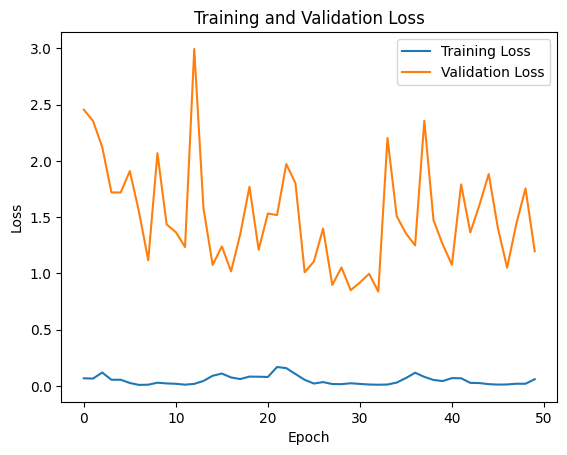

In [ ]:

# ---- Training / Validation Loss Curve ----

import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()


**Confusion matrix**

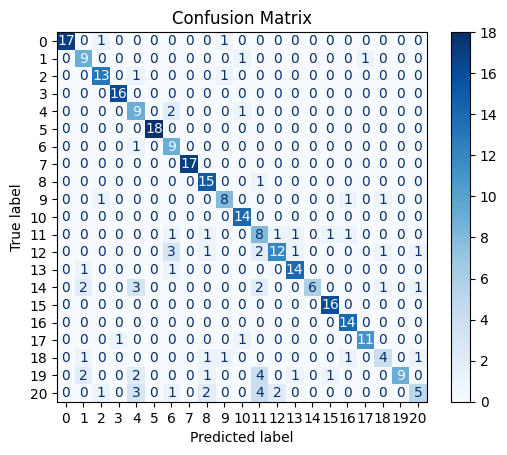

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

**DISCUSSION**

**Assignment 1:**
Z-score normalization was implemented by randomly sampling 30% of the dataset and computing per-band statistics. The resulting mean and standard deviation were Mean = [120.63, 122.93, 112.55] and Std = [56.44, 52.20, 50.54]. These values were stored in a pickle file and later loaded to normalize all input images prior to model training.

**Assignment 2:**
The UCMerced dataset was split into 1470 training, 315 validation, and 315 test samples. A ResNet-50 model was trained for 50 epochs using horizontal flip, vertical flip, random crop, and random hue augmentation. The model achieved OA = 0.775, Precision = 0.807, Recall = 0.775, and F1-score = 0.766. The loss curves show stable learning with some validation variability, and the confusion matrix indicates generally strong class predictions with some confusion between visually similar land-use classes.